In [1]:
# 01_download_explore.ipynb - Завантаження та перший аналіз даних
# Мета: завантажити датасет Yoochoose, провести первинний аналіз та зберегти базову інформацію

import sys
sys.path.append('..')

import os
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / 'data' / 'yoochoose'

# Створюємо папку (exist_ok=True дозволяє пропустити якщо вже існує)
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Папка для даних: {DATA_DIR}")

# Перевіряємо права на запис
test_file = DATA_DIR / 'test.txt'
try:
    with open(test_file, 'w') as f:
        f.write('test')
    os.remove(test_file)
    print("Права на запис є")
except Exception as e:
    print(f"Помилка запису: {e}")

print("\nСередовище налаштовано")

Папка для даних: d:\University\kursova\kursova\data\yoochoose
Права на запис є

Середовище налаштовано


Завантаження даних

 Завантажено:
   Clicks: 33,003,944 записів
   Buys:   1,150,753 записів
Структура даних

Clicks (перші 5 рядків):


,Session_ID,Timestamp,Item_ID,Category
0,1,2014-04-07 10:51:09.277000+00:00,214536502,0
1,1,2014-04-07 10:54:09.868000+00:00,214536500,0
2,1,2014-04-07 10:54:46.998000+00:00,214536506,0
3,1,2014-04-07 10:57:00.306000+00:00,214577561,0
4,2,2014-04-07 13:56:37.614000+00:00,214662742,0



Buys (перші 5 рядків):


,Session_ID,Timestamp,Item_ID,Price,Quantity
0,420374,2014-04-06 18:44:58.314000+00:00,214537888,12462,1
1,420374,2014-04-06 18:44:58.325000+00:00,214537850,10471,1
2,281626,2014-04-06 09:40:13.032000+00:00,214535653,1883,1
3,420368,2014-04-04 06:13:28.848000+00:00,214530572,6073,1
4,420368,2014-04-04 06:13:28.858000+00:00,214835025,2617,1


КРОК 3: Базова інформація

 Clicks:
   Формат: 33,003,944 рядків, 4 колонок
   Розмір в пам'яті: ~2582 MB

 Buys:
   Формат: 1,150,753 рядків, 5 колонок
   Розмір в пам'яті: ~44 MB
Ключові статистики

 УНІКАЛЬНІ ЗНАЧЕННЯ:
   Сесій:           9,249,729
   Товарів:         52,739
   Категорій:       339
   Сесій з покупками: 509,696 (5.51%)

 ЧАСОВИЙ ДІАПАЗОН:
   Початок: 2014-04-01 03:00:00.124000+00:00
   Кінець:  2014-09-30 02:59:59.430000+00:00
   Тривалість: 181 days 23:59:59.306000

 ДОВЖИНА СЕСІЙ:
   Середня: 3.57 подій
   Медіана: 2 подій
   Максимум: 200 подій
   95-й перцентиль: 9 подій
Візуалізація даних


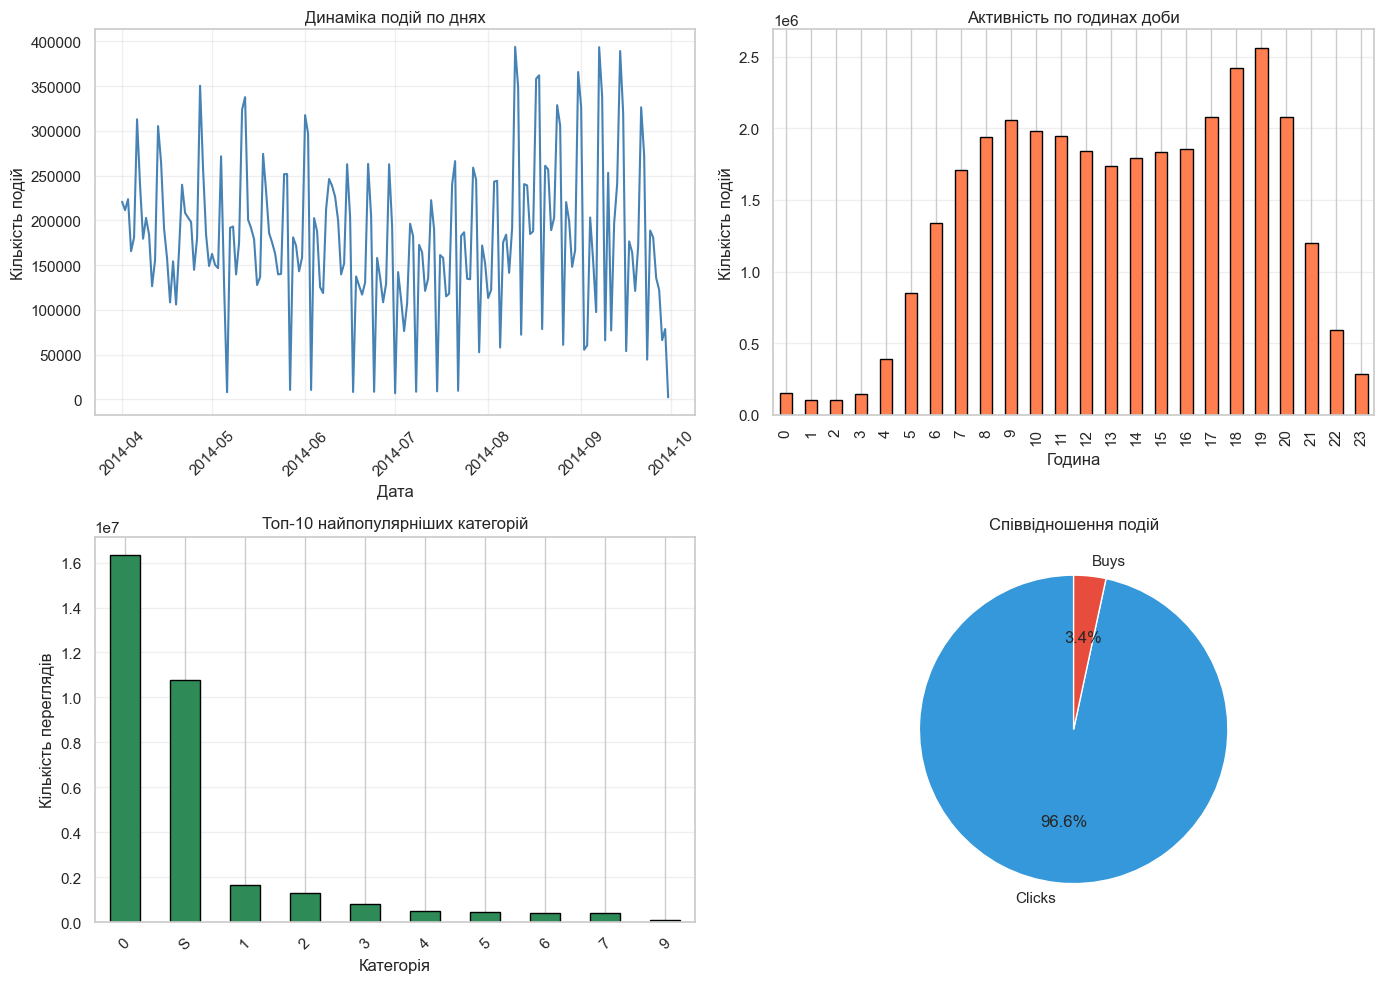

Графіки збережено: figures/eda/initial_overview.png
 Збереження результатів
Інформацію збережено: d:\University\kursova\kursova\notebooks\..\data\yoochoose\dataset_info.json
ВИСНОВОК

Дані успішно завантажено та проаналізовано.

КЛЮЧОВІ ВИСНОВКИ:
   • Всього сесій: 9,249,729
   • Конверсія (покупки): 5.51%
   • Середня довжина сесії: 3.57 подій
   • Пік активності: 19:00 (2,562,235 подій)

РЕКОМЕНДАЦІЇ:
   • Використовувати максимальну довжину сесії = 9
   • Враховувати часові патерни при моделюванні
   • Балансувати класи через дисбаланс 5.5% / 94.5%




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from src.config import DATA_DIR
from src.data_loader import download_yoochoose, load_clicks, load_buys

%matplotlib inline

# Налаштування візуалізації 
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

# Завантажуємо дані (якщо файли вже є - пропускаємо)
print("Завантаження даних")
download_yoochoose()
clicks = load_clicks()
buys = load_buys()

print(f"\n Завантажено:")
print(f"   Clicks: {len(clicks):,} записів")
print(f"   Buys:   {len(buys):,} записів")

# Перший погляд на структуру даних
print("Структура даних")

print(f"\nClicks (перші 5 рядків):")
display(clicks.head())

print(f"\nBuys (перші 5 рядків):")
display(buys.head())

# Базова інформація про дані
print("КРОК 3: Базова інформація")

# Коротка статистика
print(f"\n Clicks:")
print(f"   Формат: {clicks.shape[0]:,} рядків, {clicks.shape[1]} колонок")
print(f"   Розмір в пам'яті: ~{clicks.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

print(f"\n Buys:")
print(f"   Формат: {buys.shape[0]:,} рядків, {buys.shape[1]} колонок")
print(f"   Розмір в пам'яті: ~{buys.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

# Ключові статистики
print("Ключові статистики")

# Унікальні значення
n_sessions = clicks['Session_ID'].nunique()
n_items = clicks['Item_ID'].nunique()
n_categories = clicks['Category'].nunique()
n_buy_sessions = buys['Session_ID'].nunique() if len(buys) > 0 else 0
conversion_rate = n_buy_sessions / n_sessions * 100 if n_sessions > 0 else 0

print(f"\n УНІКАЛЬНІ ЗНАЧЕННЯ:")
print(f"   Сесій:           {n_sessions:,}")
print(f"   Товарів:         {n_items:,}")
print(f"   Категорій:       {n_categories:,}")
print(f"   Сесій з покупками: {n_buy_sessions:,} ({conversion_rate:.2f}%)")

# Часовий діапазон
print(f"\n ЧАСОВИЙ ДІАПАЗОН:")
print(f"   Початок: {clicks['Timestamp'].min()}")
print(f"   Кінець:  {clicks['Timestamp'].max()}")
print(f"   Тривалість: {clicks['Timestamp'].max() - clicks['Timestamp'].min()}")

# Довжина сесій
session_lengths = clicks.groupby('Session_ID').size()
print(f"\n ДОВЖИНА СЕСІЙ:")
print(f"   Середня: {session_lengths.mean():.2f} подій")
print(f"   Медіана: {session_lengths.median():.0f} подій")
print(f"   Максимум: {session_lengths.max():.0f} подій")
print(f"   95-й перцентиль: {session_lengths.quantile(0.95):.0f} подій")

# Візуалізація
print("Візуалізація даних")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Динаміка подій по днях
clicks['Date'] = clicks['Timestamp'].dt.date
daily_counts = clicks.groupby('Date').size()
daily_counts.plot(ax=axes[0, 0], color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Динаміка подій по днях')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Кількість подій')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Активність по годинах
clicks['Hour'] = clicks['Timestamp'].dt.hour
hourly_counts = clicks.groupby('Hour').size()
hourly_counts.plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Активність по годинах доби')
axes[0, 1].set_xlabel('Година')
axes[0, 1].set_ylabel('Кількість подій')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Топ-10 категорій
top_categories = clicks['Category'].value_counts().head(10)
top_categories.plot(kind='bar', ax=axes[1, 0], color='seagreen', edgecolor='black')
axes[1, 0].set_title('Топ-10 найпопулярніших категорій')
axes[1, 0].set_xlabel('Категорія')
axes[1, 0].set_ylabel('Кількість переглядів')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Співвідношення clicks та buys
axes[1, 1].pie([len(clicks), len(buys)], 
               labels=['Clicks', 'Buys'], 
               autopct='%1.1f%%',
               colors=['#3498db', '#e74c3c'],
               startangle=90)
axes[1, 1].set_title('Співвідношення подій')

plt.tight_layout()
plt.savefig('../figures/eda/initial_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print("Графіки збережено: figures/eda/initial_overview.png")

# Збереження результатів
print(" Збереження результатів")

dataset_info = {
    'total_clicks': int(len(clicks)),
    'total_buys': int(len(buys)),
    'unique_sessions': int(n_sessions),
    'unique_items': int(n_items),
    'unique_categories': int(n_categories),
    'sessions_with_purchase': int(n_buy_sessions),
    'conversion_rate': float(conversion_rate),
    'avg_session_length': float(session_lengths.mean()),
    'median_session_length': float(session_lengths.median()),
    'max_session_length': int(session_lengths.max()),
    'p95_session_length': float(session_lengths.quantile(0.95)),
    'date_range_start': str(clicks['Timestamp'].min()),
    'date_range_end': str(clicks['Timestamp'].max()),
    'peak_hour': int(hourly_counts.idxmax()),
    'peak_hour_events': int(hourly_counts.max())
}

with open(DATA_DIR / 'dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=4, default=str)

print(f"Інформацію збережено: {DATA_DIR / 'dataset_info.json'}")

# Висновок
print("ВИСНОВОК")
print(f"""
Дані успішно завантажено та проаналізовано.

КЛЮЧОВІ ВИСНОВКИ:
   • Всього сесій: {n_sessions:,}
   • Конверсія (покупки): {conversion_rate:.2f}%
   • Середня довжина сесії: {session_lengths.mean():.2f} подій
   • Пік активності: {hourly_counts.idxmax()}:00 ({hourly_counts.max():,} подій)

РЕКОМЕНДАЦІЇ:
   • Використовувати максимальну довжину сесії = {int(session_lengths.quantile(0.95))}
   • Враховувати часові патерни при моделюванні
   • Балансувати класи через дисбаланс {conversion_rate:.1f}% / {(100-conversion_rate):.1f}%

""")
